In [13]:
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

In [14]:
with open(r"C:\Users\Vasala Vignesh\Documents\sem5\NLP\Hyderabadi Biryani.txt",
          "r",
          encoding="utf-8") as file:
    original_text = file.read()

print("Original Text:\n")
print(original_text)

Original Text:

My favorite food is Hyderabadi Biryani.
It is one of the most popular dishes in India.
Hyderabadi Biryani originated in Hyderabad.
It is made with basmati rice, chicken, and aromatic spices.
The biryani is cooked using the traditional dum method.
It is usually served with raita and mirchi ka salan.
I love its rich aroma and delicious taste.
I enjoy eating Hyderabadi Biryani with my family on special occasions.
Every bite is full of flavor and tender chicken.
Hyderabadi Biryani is my all-time favorite food because it is tasty and satisfying.


In [15]:
docs = sent_tokenize(original_text)

print("Documents:\n")

for i, document in enumerate(docs, 1):
    print(f"D{i}: {document}")

print("\nTotal Number of Documents:", len(docs))

Documents:

D1: My favorite food is Hyderabadi Biryani.
D2: It is one of the most popular dishes in India.
D3: Hyderabadi Biryani originated in Hyderabad.
D4: It is made with basmati rice, chicken, and aromatic spices.
D5: The biryani is cooked using the traditional dum method.
D6: It is usually served with raita and mirchi ka salan.
D7: I love its rich aroma and delicious taste.
D8: I enjoy eating Hyderabadi Biryani with my family on special occasions.
D9: Every bite is full of flavor and tender chicken.
D10: Hyderabadi Biryani is my all-time favorite food because it is tasty and satisfying.

Total Number of Documents: 10


In [16]:
query = "hyderabadi biryani delicious rice spices"

print("Query:\n")
print(query)

Query:

hyderabadi biryani delicious rice spices


In [17]:
stop_words = set(stopwords.words("english"))

In [18]:
def preprocess_text(text):

    text = text.lower()

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    words = word_tokenize(text)

    filtered_words = [
        word
        for word in words
        if word not in stop_words
    ]

    processed_text = " ".join(filtered_words)

    return processed_text

In [19]:
processed_docs = [
    preprocess_text(document)
    for document in docs
]

processed_query = preprocess_text(query)

print("Processed Documents:\n")

for i, document in enumerate(processed_docs, 1):
    print(f"D{i}: {document}")

print("\nProcessed Query:")
print(processed_query)

Processed Documents:

D1: favorite food hyderabadi biryani
D2: one popular dishes india
D3: hyderabadi biryani originated hyderabad
D4: made basmati rice chicken aromatic spices
D5: biryani cooked using traditional dum method
D6: usually served raita mirchi ka salan
D7: love rich aroma delicious taste
D8: enjoy eating hyderabadi biryani family special occasions
D9: every bite full flavor tender chicken
D10: hyderabadi biryani alltime favorite food tasty satisfying

Processed Query:
hyderabadi biryani delicious rice spices


In [20]:
all_texts = processed_docs + [processed_query]

print("Number of Documents:", len(processed_docs))
print("Total Texts Including Query:", len(all_texts))

Number of Documents: 10
Total Texts Including Query: 11


In [21]:
labels = [
    f"D{i}"
    for i in range(1, len(docs) + 1)
]

labels.append("Query")

print(labels)

['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'Query']


In [22]:
vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(all_texts)

tfidf_array = tfidf_matrix.toarray()

feature_names = vectorizer.get_feature_names_out()

print("TF-IDF Matrix Shape:", tfidf_array.shape)

print("Vocabulary Size:", len(feature_names))

TF-IDF Matrix Shape: (11, 45)
Vocabulary Size: 45


In [23]:
tfidf_table = pd.DataFrame(
    tfidf_array,
    index=labels,
    columns=feature_names
)

print(tfidf_table.round(3))

       alltime  aroma  aromatic  basmati  biryani   bite  chicken  cooked  \
D1       0.000   0.00     0.000    0.000    0.377  0.000    0.000   0.000   
D2       0.000   0.00     0.000    0.000    0.000  0.000    0.000   0.000   
D3       0.000   0.00     0.000    0.000    0.337  0.000    0.000   0.000   
D4       0.000   0.00     0.439    0.439    0.000  0.000    0.375   0.000   
D5       0.000   0.00     0.000    0.000    0.239  0.000    0.000   0.434   
D6       0.000   0.00     0.000    0.000    0.000  0.000    0.000   0.000   
D7       0.000   0.46     0.000    0.000    0.000  0.000    0.000   0.000   
D8       0.000   0.00     0.000    0.000    0.231  0.000    0.000   0.000   
D9       0.000   0.00     0.000    0.000    0.000  0.418    0.357   0.000   
D10      0.441   0.00     0.000    0.000    0.243  0.000    0.000   0.000   
Query    0.000   0.00     0.000    0.000    0.326  0.000    0.000   0.000   

       delicious  dishes  ...  satisfying  served  special  spices  taste  

In [24]:
for i, label in enumerate(labels):

    print(f"\n{label} TF-IDF Scores:")

    for term, score in zip(feature_names, tfidf_array[i]):

        if score > 0:
            print(f"{term}: {score:.3f}")


D1 TF-IDF Scores:
biryani: 0.377
favorite: 0.585
food: 0.585
hyderabadi: 0.415

D2 TF-IDF Scores:
dishes: 0.500
india: 0.500
one: 0.500
popular: 0.500

D3 TF-IDF Scores:
biryani: 0.337
hyderabad: 0.612
hyderabadi: 0.371
originated: 0.612

D4 TF-IDF Scores:
aromatic: 0.439
basmati: 0.439
chicken: 0.375
made: 0.439
rice: 0.375
spices: 0.375

D5 TF-IDF Scores:
biryani: 0.239
cooked: 0.434
dum: 0.434
method: 0.434
traditional: 0.434
using: 0.434

D6 TF-IDF Scores:
ka: 0.408
mirchi: 0.408
raita: 0.408
salan: 0.408
served: 0.408
usually: 0.408

D7 TF-IDF Scores:
aroma: 0.460
delicious: 0.393
love: 0.460
rich: 0.460
taste: 0.460

D8 TF-IDF Scores:
biryani: 0.231
eating: 0.420
enjoy: 0.420
family: 0.420
hyderabadi: 0.255
occasions: 0.420
special: 0.420

D9 TF-IDF Scores:
bite: 0.418
chicken: 0.357
every: 0.418
flavor: 0.418
full: 0.418
tender: 0.418

D10 TF-IDF Scores:
alltime: 0.441
biryani: 0.243
favorite: 0.377
food: 0.377
hyderabadi: 0.268
satisfying: 0.441
tasty: 0.441

Query TF-IDF Scor

In [25]:
doc_vectors = tfidf_array[:-1]

query_vector = tfidf_array[-1].reshape(1, -1)

print(doc_vectors.shape)
print(query_vector.shape)

(10, 45)
(1, 45)


In [26]:
cos_sim = cosine_similarity(
    doc_vectors,
    query_vector
).flatten()

for i, similarity in enumerate(cos_sim, 1):
    print(f"D{i} vs Query: {similarity:.3f}")

D1 vs Query: 0.272
D2 vs Query: 0.000
D3 vs Query: 0.243
D4 vs Query: 0.379
D5 vs Query: 0.078
D6 vs Query: 0.000
D7 vs Query: 0.199
D8 vs Query: 0.167
D9 vs Query: 0.000
D10 vs Query: 0.175


In [27]:
similarity_table = pd.DataFrame({

    "Document": labels[:-1],

    "Original Sentence": docs,

    "Cosine Similarity": cos_sim

})

print(similarity_table.round(3))

  Document                                  Original Sentence  \
0       D1            My favorite food is Hyderabadi Biryani.   
1       D2     It is one of the most popular dishes in India.   
2       D3        Hyderabadi Biryani originated in Hyderabad.   
3       D4  It is made with basmati rice, chicken, and aro...   
4       D5  The biryani is cooked using the traditional du...   
5       D6  It is usually served with raita and mirchi ka ...   
6       D7         I love its rich aroma and delicious taste.   
7       D8  I enjoy eating Hyderabadi Biryani with my fami...   
8       D9   Every bite is full of flavor and tender chicken.   
9      D10  Hyderabadi Biryani is my all-time favorite foo...   

   Cosine Similarity  
0              0.272  
1              0.000  
2              0.243  
3              0.379  
4              0.078  
5              0.000  
6              0.199  
7              0.167  
8              0.000  
9              0.175  


In [28]:
sorted_similarity_table = similarity_table.sort_values(
    by="Cosine Similarity",
    ascending=False
).reset_index(drop=True)

print(sorted_similarity_table.round(3))

  Document                                  Original Sentence  \
0       D4  It is made with basmati rice, chicken, and aro...   
1       D1            My favorite food is Hyderabadi Biryani.   
2       D3        Hyderabadi Biryani originated in Hyderabad.   
3       D7         I love its rich aroma and delicious taste.   
4      D10  Hyderabadi Biryani is my all-time favorite foo...   
5       D8  I enjoy eating Hyderabadi Biryani with my fami...   
6       D5  The biryani is cooked using the traditional du...   
7       D2     It is one of the most popular dishes in India.   
8       D6  It is usually served with raita and mirchi ka ...   
9       D9   Every bite is full of flavor and tender chicken.   

   Cosine Similarity  
0              0.379  
1              0.272  
2              0.243  
3              0.199  
4              0.175  
5              0.167  
6              0.078  
7              0.000  
8              0.000  
9              0.000  


In [29]:
most_similar_index = np.argmax(cos_sim)

highest_similarity = cos_sim[most_similar_index]

print("Most Similar Document:\n")

print(f"D{most_similar_index + 1}:")
print(docs[most_similar_index])

print("\nCosine Similarity Score:", round(highest_similarity, 3))

Most Similar Document:

D4:
It is made with basmati rice, chicken, and aromatic spices.

Cosine Similarity Score: 0.379


In [30]:
pca = PCA(n_components=2)

reduced_vectors = pca.fit_transform(tfidf_array)

pca_table = pd.DataFrame(
    reduced_vectors,
    index=labels,
    columns=[
        "PCA Component 1",
        "PCA Component 2"
    ]
)

print(pca_table.round(3))

       PCA Component 1  PCA Component 2
D1               0.657           -0.010
D2              -0.307           -0.447
D3               0.301            0.025
D4              -0.392            0.604
D5              -0.063           -0.254
D6              -0.307           -0.447
D7              -0.299            0.122
D8               0.170           -0.065
D9              -0.404           -0.055
D10              0.622           -0.065
Query            0.021            0.592


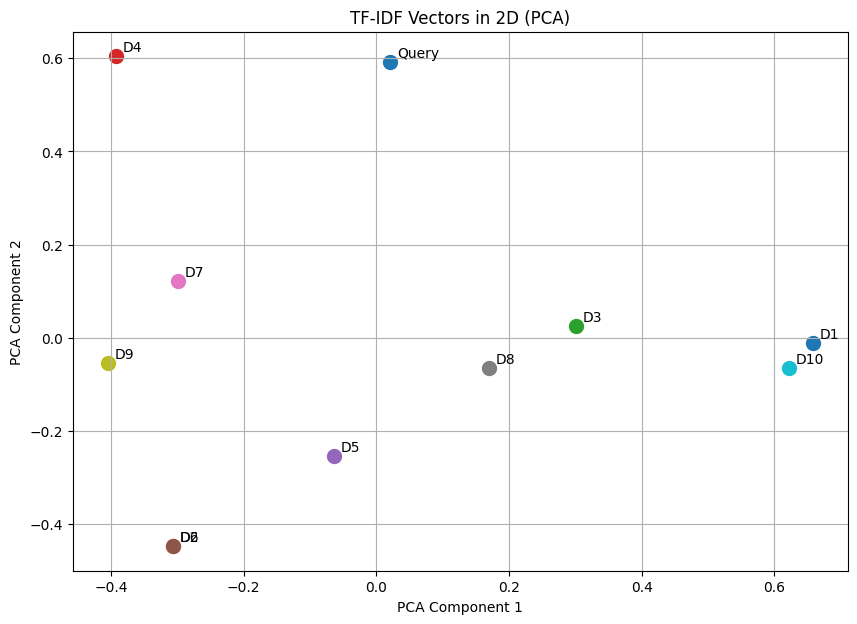

In [31]:
plt.figure(figsize=(10, 7))

for i, (x, y) in enumerate(reduced_vectors):

    plt.scatter(x, y, s=100)

    plt.text(
        x + 0.01,
        y + 0.01,
        labels[i],
        fontsize=10
    )

plt.title("TF-IDF Vectors in 2D (PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.grid(True)

plt.savefig(
    "07_tfidf_vectors_pca.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()